# Analyzing Time Series Data and perform regressional analysis with Socrata and Python

In [1]:
import os
os.getcwd()


'/Users/aparn/Downloads'

# Milestone 2

## Loading datasets into our notebook

We'll start by loading a city of Chicago permits dataset into a Pandas DataFrame. We'll use the open source sodapy Python Socrata module to do this.

In [2]:
import pandas as pd
from sodapy import Socrata

# load Chicago permits data
chicago_permits_df = pd.read_csv(r'Building_Permits_20260417.csv')

/var/folders/jl/8lv2588n6rn_qx3jcz2rj_zw0000gn/T/ipykernel_2625/4189533208.py:5: DtypeWarning: Columns (0,1,8,12,14,35,40,45,50,55,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,107) have mixed types. Specify dtype option on import or set low_memory=False.
  chicago_permits_df = pd.read_csv(r'Building_Permits_20260417.csv')


In the next few cells we'll do some exploration of our datasets using the `len`, `head`, and `value_counts` functions. We'll start by getting a sense of how many rows are in each of our datasets with the `len` function.

Now let's see have a peek at the first 10 rows in each of those dataset using the `head` method. You can optionally pass a parameter for the number of rows you want to print if 5 isn't enough.

In [3]:
print(len(chicago_permits_df))
chicago_permits_df.head(10)

833096


,ID,PERMIT#,PERMIT_STATUS,PERMIT_MILESTONE,PERMIT_TYPE,REVIEW_TYPE,APPLICATION_START_DATE,ISSUE_DATE,PROCESSING_TIME,STREET_NUMBER,...,REPORTED_COST,PIN_LIST,COMMUNITY_AREA,CENSUS_TRACT,WARD,XCOORDINATE,YCOORDINATE,LATITUDE,LONGITUDE,LOCATION
0,3368573,101046020,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,03/08/2024,09/18/2024,194,7529.0,...,"$5,500.00",NaN,1.0,10202.0,49.0,1.162912e+06,1.950065e+06,42.018631,-87.675845,POINT (-87.675844598018 42.018631130261)
1,3423504,101072844,ACTIVE,INSPECTIONS,PERMIT - RENOVATION/ALTERATION,SELF CERT,08/08/2025,10/14/2025,67,2219.0,...,"$20,000.00",1730102015,31.0,841300.0,25.0,1.161422e+06,1.889146e+06,41.851494,-87.683028,POINT (-87.683027767753 41.851494345646)
2,2486241,100498645,NaN,NaN,PERMIT - EASY PERMIT PROCESS,EASY PERMIT,07/08/2013,07/08/2013,0,2648.0,...,"$24,815.00",1429408053,7.0,70400.0,32.0,1.168462e+06,1.917958e+06,41.930408,-87.656354,POINT (-87.656354338933 41.930408052126)
3,2487337,100499294,NaN,NaN,PERMIT - EASY PERMIT PROCESS,EASY PERMIT,07/11/2013,07/11/2013,0,9426.0,...,"$7,800.00",2503429023,49.0,490400.0,9.0,1.181524e+06,1.842462e+06,41.722950,-87.610690,POINT (-87.610689567581 41.722949542022)
4,2490603,100500984,NaN,NaN,PERMIT - EASY PERMIT PROCESS,EASY PERMIT,07/23/2013,07/23/2013,0,2236.0,...,"$9,950.00",1418102025,4.0,40600.0,47.0,1.160442e+06,1.931543e+06,41.967856,-87.685451,POINT (-87.685451345211 41.9678557176)
5,2502999,100508118,EXPIRED,INSPECTIONS,PERMIT - RENOVATION/ALTERATION,STANDARD PLAN REVIEW,09/27/2013,09/27/2013,0,3140.0,...,"$5,000.00",1325108007,21.0,210700.0,33.0,1.156123e+06,1.920774e+06,41.938394,-87.701623,POINT (-87.701622534072 41.938394321835)
6,2505730,100509770,NaN,NaN,PERMIT - EASY PERMIT PROCESS,EASY PERMIT,09/20/2013,09/20/2013,0,1842.0,...,"$15,000.00",1336311029,22.0,222600.0,35.0,1.156038e+06,1.912280e+06,41.915089,-87.702166,POINT (-87.702165580572 41.915088795478)
7,2512402,100513804,COMPLETE,COMPLETE,PERMIT - RENOVATION/ALTERATION,SELF CERT,10/25/2013,11/19/2013,25,3236.0,...,"$50,000.00",1602228025,23.0,230900.0,26.0,1.154430e+06,1.907837e+06,41.902928,-87.708190,POINT (-87.708190452612 41.902927901185)
8,2520056,100518233,NaN,NaN,PERMIT - EASY PERMIT PROCESS,EASY PERMIT,11/19/2013,11/25/2013,6,1009.0,...,"$60,000.00",1706414021,24.0,242200.0,1.0,1.163258e+06,1.906796e+06,41.899891,-87.675793,POINT (-87.675792736419 41.89989084174)
9,2546810,100532323,COMPLETE,COMPLETE,PERMIT - RENOVATION/ALTERATION,STANDARD PLAN REVIEW,04/22/2014,04/23/2014,1,1318.0,...,"$25,000.00",1405118022,77.0,30200.0,48.0,1.166293e+06,1.941006e+06,41.993699,-87.663665,POINT (-87.663664520289 41.993699163013)


Printing our dataframes like this gives us a sense of what columns exist, and quick sense of some of the values in the dataset. But there's an even better way to detrmine the top values for a particular column -- the `value_counts` method.

In [4]:
chicago_permits_df["APPLICATION_START_DATE"].value_counts(dropna=False).head(10)

APPLICATION_START_DATE
10/16/2007    366
NaN           349
05/25/2016    346
08/14/2019    341
03/07/2017    328
03/30/2011    321
04/23/2012    321
03/13/2006    321
09/22/2014    316
07/19/2006    315
Name: count, dtype: int64

## Select a subset of a DataFrame & Deal with missing values

In [5]:
chicago_permits_df.shape

(833096, 116)

In [6]:
chicago_permits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833096 entries, 0 to 833095
Columns: 116 entries, ID to LOCATION
dtypes: float64(9), object(107)
memory usage: 737.3+ MB


In [7]:
print(chicago_permits_df.isnull().sum())

ID                       0
PERMIT#                  0
PERMIT_STATUS       322607
PERMIT_MILESTONE    322607
PERMIT_TYPE              0
                     ...  
XCOORDINATE           1158
YCOORDINATE           1158
LATITUDE             12786
LONGITUDE            12786
LOCATION             12786
Length: 116, dtype: int64


There are too many columns to analysize and we probably do not care the information in all the columns. So let's only select part of the dataframe we care about. Please make your own decision of columns selection based on what you would like to observie.

In [8]:
chicago_permits_df.columns

Index(['ID', 'PERMIT#', 'PERMIT_STATUS', 'PERMIT_MILESTONE', 'PERMIT_TYPE',
       'REVIEW_TYPE', 'APPLICATION_START_DATE', 'ISSUE_DATE',
       'PROCESSING_TIME', 'STREET_NUMBER',
       ...
       'REPORTED_COST', 'PIN_LIST', 'COMMUNITY_AREA', 'CENSUS_TRACT', 'WARD',
       'XCOORDINATE', 'YCOORDINATE', 'LATITUDE', 'LONGITUDE', 'LOCATION'],
      dtype='object', length=116)

In [10]:
chicago_permits_df_sub = chicago_permits_df[['ID', 'PERMIT#', 'PERMIT_TYPE', 'REVIEW_TYPE', 'APPLICATION_START_DATE','STREET_DIRECTION','COMMUNITY_AREA','LATITUDE', 'LONGITUDE', 'LOCATION']]

In [11]:
chicago_permits_df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833096 entries, 0 to 833095
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      833096 non-null  object 
 1   PERMIT#                 833096 non-null  object 
 2   PERMIT_TYPE             833096 non-null  object 
 3   REVIEW_TYPE             833088 non-null  object 
 4   APPLICATION_START_DATE  832747 non-null  object 
 5   STREET_DIRECTION        833051 non-null  object 
 6   COMMUNITY_AREA          758093 non-null  float64
 7   LATITUDE                820310 non-null  float64
 8   LONGITUDE               820310 non-null  float64
 9   LOCATION                820310 non-null  object 
dtypes: float64(3), object(7)
memory usage: 63.6+ MB


The value counts make it clear that a lot of the values in the "application_start_date" column are missing or null. There a variety of ways you can handle missing data, but removing incomplete rows is the simplest. In the next cell, we'll remove rows with null dates. There are also a lot of columns in the permits dataset that we won't use in this analysis. So we'll also filter down our dataset to just the columns we're interested in to reduce the amount of extraneous information.

In [12]:
chicago_permits_df_sub_notnull = chicago_permits_df_sub[chicago_permits_df_sub["APPLICATION_START_DATE"].notnull()]
chicago_permits_df_sub_notnull = chicago_permits_df_sub_notnull[["APPLICATION_START_DATE"]].reset_index(drop=True)
chicago_permits_df_sub_notnull.head(10)

,APPLICATION_START_DATE
0,03/08/2024
1,08/08/2025
2,07/08/2013
3,07/11/2013
4,07/23/2013
5,09/27/2013
6,09/20/2013
7,10/25/2013
8,11/19/2013
9,04/22/2014


## Print descriptive statistics

Use info() to get some basic summary about the dataframe, and also describe() helps us to get some descriptive statistics about columns containing the numeric values.

In [13]:
chicago_permits_df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833096 entries, 0 to 833095
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      833096 non-null  object 
 1   PERMIT#                 833096 non-null  object 
 2   PERMIT_TYPE             833096 non-null  object 
 3   REVIEW_TYPE             833088 non-null  object 
 4   APPLICATION_START_DATE  832747 non-null  object 
 5   STREET_DIRECTION        833051 non-null  object 
 6   COMMUNITY_AREA          758093 non-null  float64
 7   LATITUDE                820310 non-null  float64
 8   LONGITUDE               820310 non-null  float64
 9   LOCATION                820310 non-null  object 
dtypes: float64(3), object(7)
memory usage: 63.6+ MB


In [14]:
chicago_permits_df_sub.describe()

,COMMUNITY_AREA,LATITUDE,LONGITUDE
count,758093.000000,820310.000000,820310.000000
mean,31.803335,41.869619,-87.673230
std,22.012574,0.096069,0.113838
min,0.000000,0.000000,-87.940225
25%,12.000000,41.801970,-87.707894
50%,28.000000,41.885830,-87.662896
75%,47.000000,41.931063,-87.632167
max,77.000000,42.022780,0.000000


## Aggregating based on date

For the purpose of analysizing APPLICATION_START_DATE distribution (feel free to explore other variables), in the dataframe "chicago_permits_df_sub_notnull", each row in our dataset corresponds to a permit application and the only column we've preserved is the date of the application. The task of forecasting number of permit applications is not really interesting (or reliable) at the granularity of day. Predicting at the granularity of week might be interesting, but let's start by grouping by month. To get some datatime functionality from Python, we'll convert our date column to a datetime type.

In [15]:
import datetime

fixed_dates_df = chicago_permits_df_sub_notnull.copy()
fixed_dates_df["APPLICATION_START_DATE"] = fixed_dates_df["APPLICATION_START_DATE"].apply(pd.to_datetime)
fixed_dates_df = fixed_dates_df.set_index(fixed_dates_df["APPLICATION_START_DATE"])
grouped = fixed_dates_df.resample("M").count()
data_df = pd.DataFrame({"count": grouped.values.flatten()}, index=grouped.index)
data_df.head(10)

,count
APPLICATION_START_DATE,
2000-10-31,1
2000-11-30,1
2000-12-31,0
2001-01-31,1
2001-02-28,0
2001-03-31,1
2001-04-30,1
2001-05-31,0
2001-06-30,1


## Plotting a histogram

array([[<Axes: title={'center': 'COMMUNITY_AREA'}>,
        <Axes: title={'center': 'LATITUDE'}>],
       [<Axes: title={'center': 'LONGITUDE'}>, <Axes: >]], dtype=object)

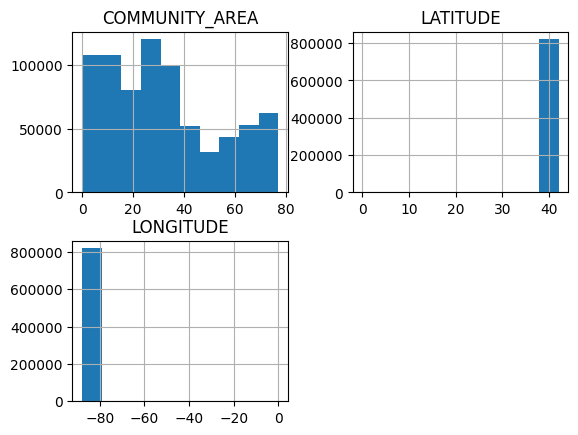

In [16]:
chicago_permits_df_sub.hist()

## Plotting a time series

<Axes: xlabel='APPLICATION_START_DATE'>

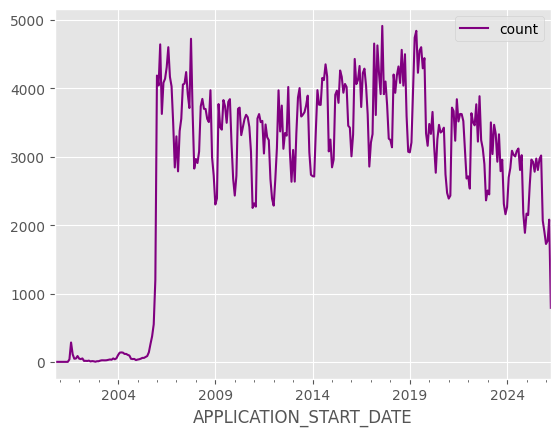

In [17]:
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
plt.style.use("ggplot")

data_df.plot(color="purple")

Notice how the number of applications in 2005 and before looks suspiciously low. My intuition is that this is a data problem. Let's remove all data from before 2006, since bad data will impact the accuracy of our model. Let's also remove data from before October of this year, since October is incomplete.

<Axes: xlabel='APPLICATION_START_DATE'>

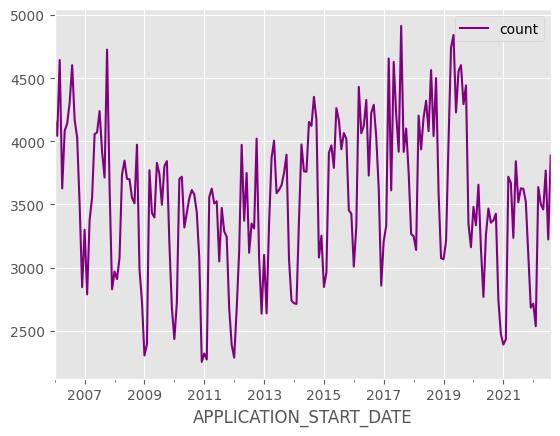

In [18]:
def is_between_2006_and_now(date):
    return date > datetime.datetime(2006, 1, 1) and date < datetime.datetime(2022, 9, 27)

data_df = data_df[data_df.index.to_series().apply(is_between_2006_and_now)]
data_df.plot(color="purple")

This plot makes two things pretty clear. First, there are some clear trends in the time series -- for example, an increase between 2011 and 2017, followed by a levelling off of permit applications. Second, there is a cyclic nature to the time series, which is indicative of there being seasonal variation in permit applications (which isn't surprising).

## Understanding long-term trends and seasonality
The types of modeling used on time series assume "stationarity". For a time series to be stationary, mean and variance should be constant over time (and of course, most real life time series will not be stationary). To satisfy this assumption, we need to remove trend and seasonality from our series. The underlying modeling code we will use will do this for us. Doing this ourselves explicitly enables us to make educated guesses about reasonable parameters for our model. We'll use the `seasonal_decompose` function to do this.

In [20]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 12.1 MB/s eta 0:00:0000:010:01

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


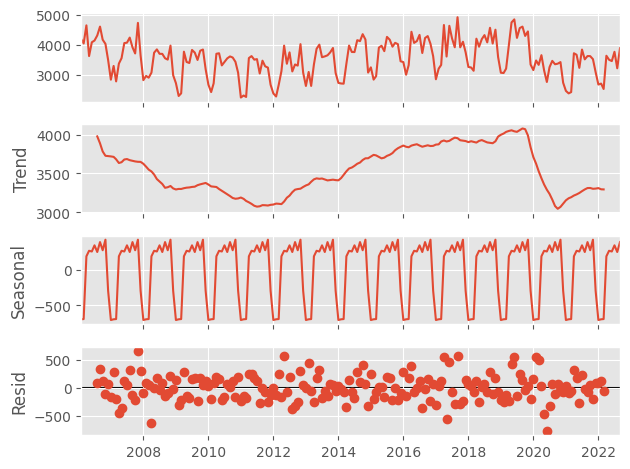

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data_df)
fig = result.plot()

## Forecasting with Prophet
Next, we'll create a Prophet model. Doing so requires only that we rename our count column, and that we have a new column "ds" which is our timestamps. After training our model, we'll use it to predict a year into the future.

In [23]:
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 16.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
from prophet import Prophet
model = Prophet()
train_df = data_df.rename(columns={"count":'y'})
train_df["ds"] = train_df.index
model.fit(train_df)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
23:18:32 - cmdstanpy - INFO - Chain [1] start processing
23:18:32 - cmdstanpy - INFO - Chain [1] done processing


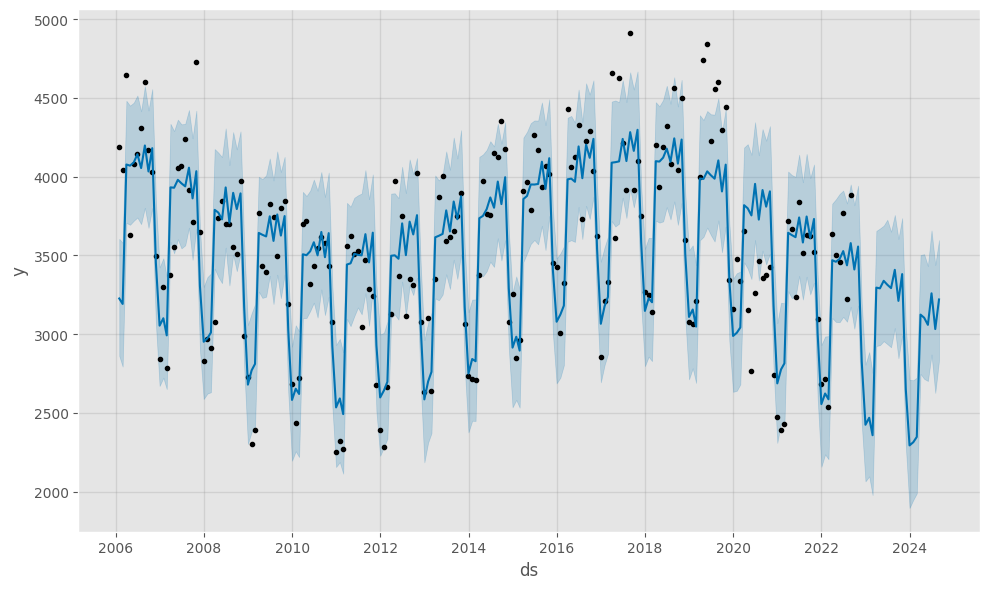

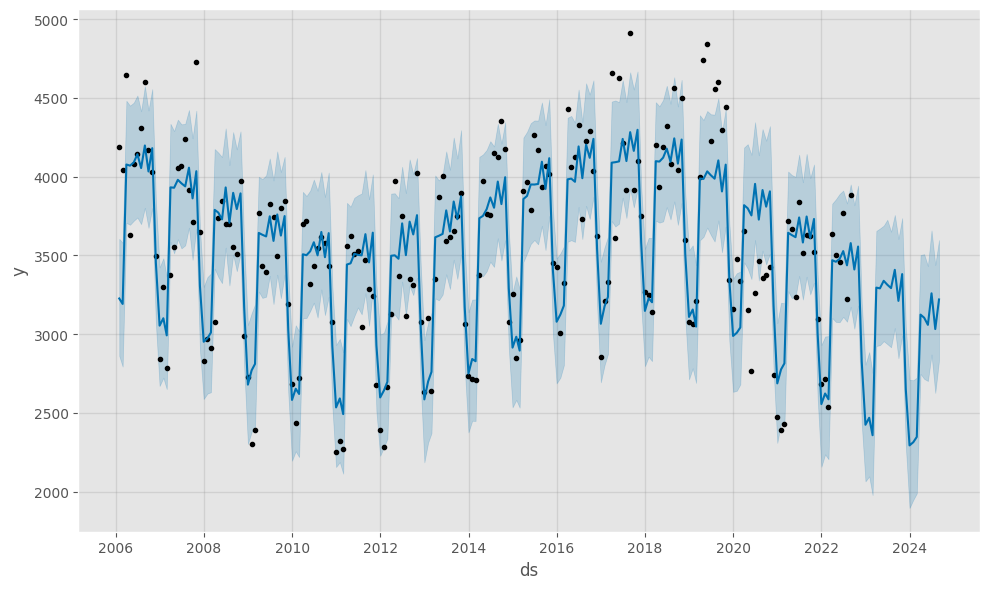

In [25]:
pd.plotting.register_matplotlib_converters()
future = model.make_future_dataframe(24, freq='M', include_history=True)
forecast = model.predict(future)
model.plot(forecast)

In [26]:
train_df

,y,ds
APPLICATION_START_DATE,,
2006-01-31,4188,2006-01-31
2006-02-28,4043,2006-02-28
2006-03-31,4644,2006-03-31
2006-04-30,3627,2006-04-30
2006-05-31,4083,2006-05-31
...,...,...
2022-04-30,3504,2022-04-30
2022-05-31,3460,2022-05-31
2022-06-30,3768,2022-06-30


In [27]:
train_df.size

400

Export the Chicago data portal "Sidewalk_Cafe_Permits.csv" from https://data.cityofchicago.org/Community-Economic-Development/Sidewalk-Cafe-Permits/nxj5-ix6z
Please also read the description about this dateset. 

In [28]:
sidewalk_cafe_df = pd.read_csv("Sidewalk_Cafe_Permits_20260417.csv")
sidewalk_cafe_df_not_null = sidewalk_cafe_df.dropna()
sidewalk_cafe_df_not_null_reset_index = sidewalk_cafe_df_not_null.reset_index(drop=True)
sidewalk_cafe_date_df = sidewalk_cafe_df_not_null_reset_index[['ISSUED DATE']]

### Time series

In [29]:
fixed_cafe_dates_df = sidewalk_cafe_date_df.copy()
fixed_cafe_dates_df["ISSUED DATE"] = fixed_cafe_dates_df["ISSUED DATE"].apply(pd.to_datetime)
fixed_cafe_dates_df = fixed_cafe_dates_df.set_index(fixed_cafe_dates_df["ISSUED DATE"])
grouped_cafe_dates = fixed_cafe_dates_df.resample("M").count()
data_cafe_df = pd.DataFrame({"count": grouped_cafe_dates.values.flatten()}, index=grouped_cafe_dates.index)
data_cafe_df.head(10)

,count
ISSUED DATE,
2001-03-31,53
2001-04-30,170
2001-05-31,137
2001-06-30,66
2001-07-31,17
2001-08-31,7
2001-09-30,4
2001-10-31,5
2001-11-30,1


<Axes: xlabel='ISSUED DATE'>

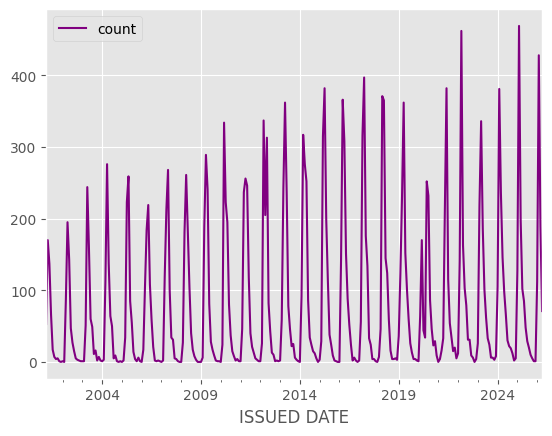

In [30]:
data_cafe_df.plot(color="purple")

<Axes: xlabel='ISSUED DATE'>

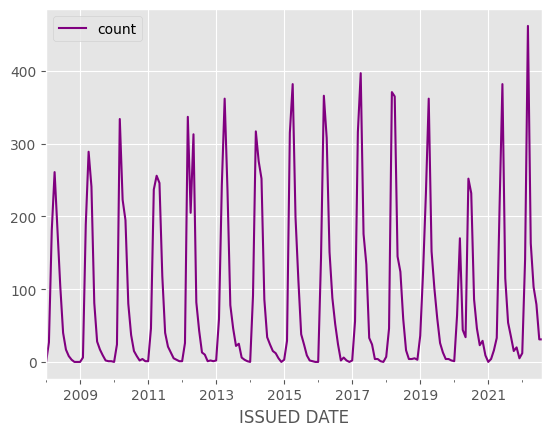

In [31]:
def is_between_2008_and_now(date):
    return date > datetime.datetime(2008, 1, 1) and date < datetime.datetime(2022, 9, 27)

data_cafe_df = data_cafe_df[data_cafe_df.index.to_series().apply(is_between_2008_and_now)]
data_cafe_df.plot(color="purple")

<Axes: xlabel='APPLICATION_START_DATE'>

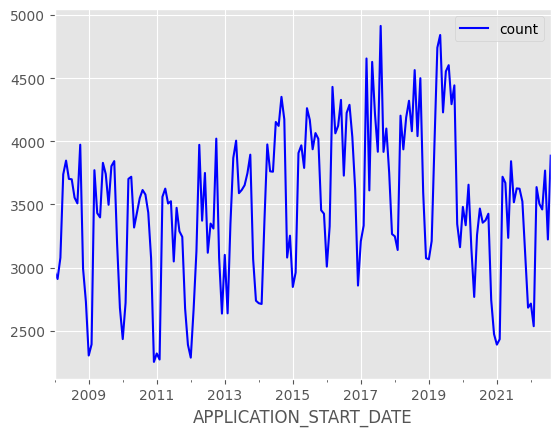

In [32]:
dataperm_df = data_df[data_df.index.to_series().apply(is_between_2008_and_now)]
dataperm_df.plot(color="blue")

## Simple linear regression

We will explore the relationship between building permits and sidewalk cafe permits, using simple linear regression.

In [33]:
perms, cafe = dataperm_df.to_numpy(), data_cafe_df.to_numpy()

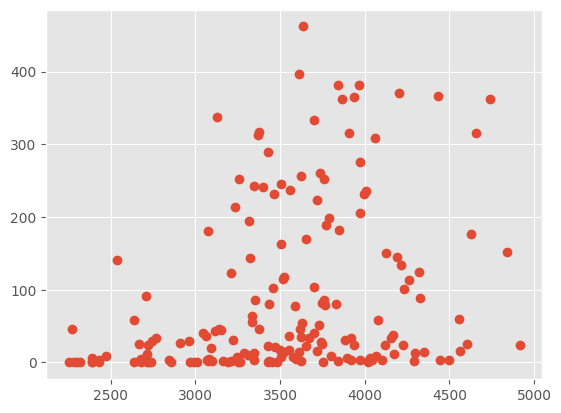

In [34]:
_ = plt.plot(perms,cafe,'o')

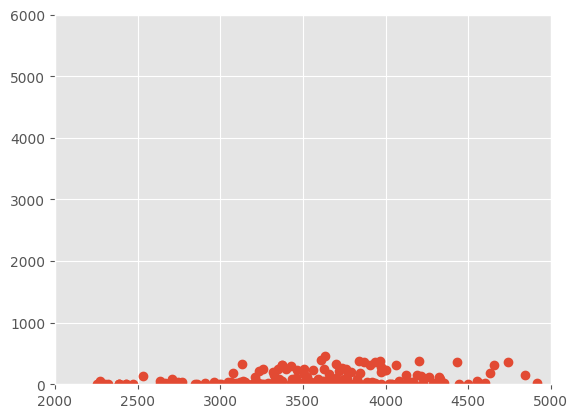

In [35]:
_ = plt.plot(perms,cafe,'o')
_ = plt.ylim([0,6000])
_ = plt.xlim([2000,5000])
plt.show()

In [36]:
import numpy as np
AA = np.vstack([perms.T, np.ones(len(perms))]).T
AA.shape

(176, 2)

In [37]:
m,c = np.linalg.lstsq(AA,cafe,rcond=None)[0]

/var/folders/jl/8lv2588n6rn_qx3jcz2rj_zw0000gn/T/ipykernel_2625/1894292922.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  _ = plt.plot(perms,m*perms+c, 'r', label='Fitted line cafe = %.2f permits + %.2f' %(m,c))


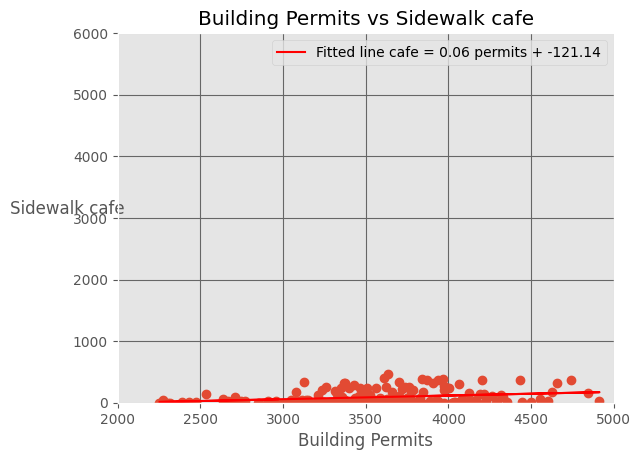

In [40]:
_ = plt.plot(perms,cafe,'o')
_ = plt.plot(perms,m*perms+c, 'r', label='Fitted line cafe = %.2f permits + %.2f' %(m,c))
_ = plt.legend()
_ = plt.xlabel('Building Permits')
_ = plt.ylabel('Sidewalk cafe', rotation='horizontal')
_ = plt.title('Building Permits vs Sidewalk cafe')
_ = plt.xlim([2000,5000])
_ = plt.ylim([0,6000])
_ = plt.grid(visible=True, which='major', color='#666666', linestyle='-')
plt.show()

In [41]:
# remove outlier and redo the regression:
cafe[cafe.argmax()]=cafe.mean()

/var/folders/jl/8lv2588n6rn_qx3jcz2rj_zw0000gn/T/ipykernel_2625/1811467407.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  _ = plt.plot(perms,m*perms+c, 'r', label='Fitted line cafe = %.2f permits + %.2f' %(m,c))


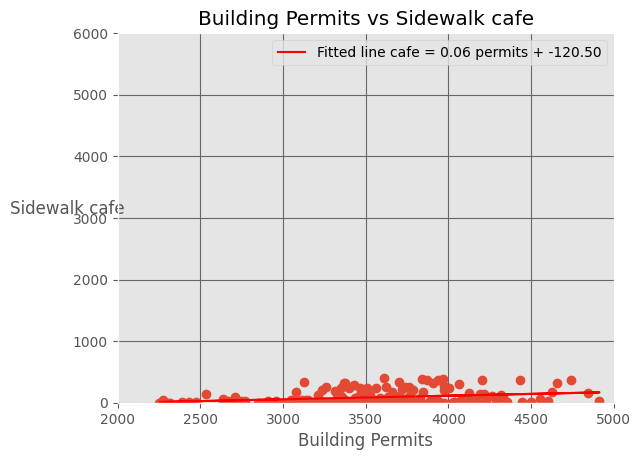

In [43]:
AA = np.vstack([perms.T, np.ones(len(perms))]).T
m,c = np.linalg.lstsq(AA,cafe,rcond=None)[0]
_ = plt.plot(perms,cafe,'o')
_ = plt.plot(perms,m*perms+c, 'r', label='Fitted line cafe = %.2f permits + %.2f' %(m,c))
_ = plt.legend()
_ = plt.xlabel('Building Permits')
_ = plt.ylabel('Sidewalk cafe', rotation='horizontal')
_ = plt.title('Building Permits vs Sidewalk cafe')
_ = plt.xlim([2000,5000])
_ = plt.ylim([0,6000])
_ = plt.grid(visible=True, which='major', color='#666666', linestyle='-')
plt.show()

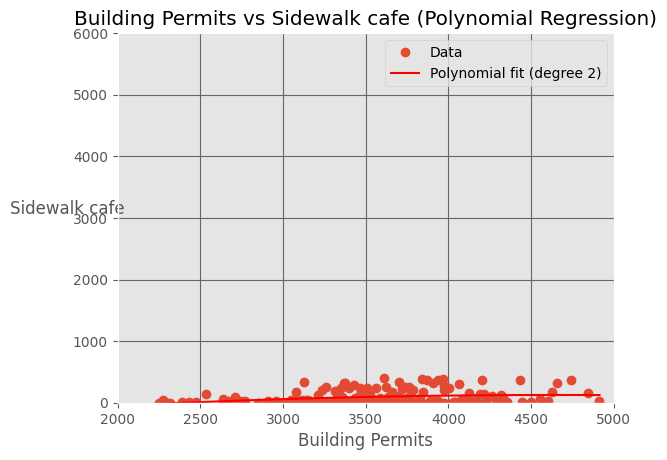

Coefficients: [-2.54433251e-05  2.35866362e-01 -4.20509541e+02]
Equation: y = -0.00x² + 0.24x + -420.51


In [46]:
#TODO: Learn Polynomial regression with the tutoriols. https://www.w3schools.com/python/python_ml_polynomial_regression.asp
#https://medium.com/analytics-vidhya/polynomial-fitting-in-python-using-just-one-line-of-code-f1638a4b3678
#Polynomial regression on the Building Permits and Sidewalk cafe dataset.
import numpy as np
import matplotlib.pyplot as plt

# Fit polynomial (degree 2)
coeffs = np.polyfit(perms.flatten(), cafe.flatten(), 2)
poly = np.poly1d(coeffs)

# Generate smooth curve for plotting
x_line = np.linspace(min(perms), max(perms), 300)
y_line = poly(x_line)

# Plot
_ = plt.plot(perms, cafe, 'o', label='Data')
_ = plt.plot(x_line, y_line, 'r', label='Polynomial fit (degree 2)')
_ = plt.legend()
_ = plt.xlabel('Building Permits')
_ = plt.ylabel('Sidewalk cafe', rotation='horizontal')
_ = plt.title('Building Permits vs Sidewalk cafe (Polynomial Regression)')
_ = plt.xlim([2000, 5000])
_ = plt.ylim([0, 6000])
_ = plt.grid(visible=True, which='major', color='#666666', linestyle='-')
plt.show()

print("Coefficients:", coeffs)
print("Equation: y = %.2fx² + %.2fx + %.2f" % (coeffs[0], coeffs[1], coeffs[2]))


# Milestone 2



### Q 1.1

Load your dataset and print the first 10 rows and any summary statistics that provide context about the data.

In [47]:
chicago_bus_ridership_df = pd.read_csv(r'CTA_-_Ridership_-_Bus_Routes_-_Daily_Totals_by_Route_20260402.csv')
chicago_population_df = pd.read_csv(r'Chicago_Population_Counts_20260402.csv')

print("=== Bus Ridership - First 10 rows ===")
print(chicago_bus_ridership_df.head(10))
print("\n=== Bus Ridership - Summary Statistics ===")
print(chicago_bus_ridership_df.describe())

print("\n=== Population Counts - First 10 rows ===")
print(chicago_population_df.head(10))
print("\n=== Population Counts - Summary Statistics ===")
print(chicago_population_df.describe())

/var/folders/jl/8lv2588n6rn_qx3jcz2rj_zw0000gn/T/ipykernel_2625/1739296711.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  chicago_bus_ridership_df = pd.read_csv(r'CTA_-_Ridership_-_Bus_Routes_-_Daily_Totals_by_Route_20260402.csv')


=== Bus Ridership - First 10 rows ===
  route        date daytype  rides
0     1  05/14/2001       W  6,217
1     1  07/06/2001       W  6,590
2     1  01/04/2001       W  6,907
3     1  04/19/2001       W  6,568
4     1  10/04/2001       W  6,361
5     1  09/14/2001       W  7,502
6     1  02/07/2001       W  7,788
7     1  04/20/2001       W  5,969
8     1  01/05/2001       W  6,154
9     1  02/22/2001       W  8,080

=== Bus Ridership - Summary Statistics ===
          route        date  daytype    rides
count   1099750     1099750  1099750  1099750
unique      190        9162        3    31901
top          70  11/30/2007        W        1
freq       9162         153   846696      468

=== Population Counts - First 10 rows ===
  Geography Type  Year Geography Population - Total Population - Age 0-17  \
0       Citywide  2018   Chicago          2,705,988               548,999   
1       ZIP Code  2018     60601             14,675                   820   
2       ZIP Code  2018     60

### Q 1.2


 Prepare the data for analysis by performing the necessary cleaning, transformation, and preprocessing steps.

In [48]:
# Bus Ridership Cleaning 

# Fix mixed type warning - convert route to string
chicago_bus_ridership_df['route'] = chicago_bus_ridership_df['route'].astype(str)

# Convert date to datetime
chicago_bus_ridership_df['date'] = pd.to_datetime(chicago_bus_ridership_df['date'])

# Remove commas from rides and convert to int
chicago_bus_ridership_df['rides'] = chicago_bus_ridership_df['rides'].str.replace(',', '').astype(int)

# Check for nulls
print("Bus Ridership nulls:\n", chicago_bus_ridership_df.isnull().sum())
print("\nBus Ridership dtypes:\n", chicago_bus_ridership_df.dtypes)
print(chicago_bus_ridership_df.describe())


# Population Counts Cleaning 

# Find numeric-looking columns with commas and convert them
for col in chicago_population_df.columns:
    if chicago_population_df[col].dtype == object:
        try:
            chicago_population_df[col] = chicago_population_df[col].str.replace(',', '').astype(float)
        except (ValueError, AttributeError):
            pass  # leave non-numeric columns as-is

# Drop rows with all null population values
chicago_population_df.dropna(how='all', inplace=True)

# Check for nulls
print("\nPopulation nulls:\n", chicago_population_df.isnull().sum())
print("\nPopulation dtypes:\n", chicago_population_df.dtypes)
print(chicago_population_df.describe())

Bus Ridership nulls:
 route      0
date       0
daytype    0
rides      0
dtype: int64

Bus Ridership dtypes:
 route              object
date       datetime64[ns]
daytype            object
rides               int64
dtype: object
                                date         rides
count                        1099750  1.099750e+06
mean   2013-04-19 21:42:35.173448704  5.835103e+03
min              2001-01-01 00:00:00  0.000000e+00
25%              2007-02-15 00:00:00  1.269000e+03
50%              2013-01-09 00:00:00  3.676000e+03
75%              2019-07-05 00:00:00  8.675000e+03
max              2026-01-31 00:00:00  4.517700e+04
std                              NaN  6.035510e+03

Population nulls:
 Geography Type                         0
Year                                   0
Geography                              0
Population - Total                     0
Population - Age 0-17                  0
Population - Age 18-29                 0
Population - Age 30-39                 0
Popul

### Q2.1


Submit at least two examples where you apply analytical techniques, such as regression, clustering, or machine learning algorithms to your datasets. 

=== Linear Regression: Rides Over Time ===
Coefficient: -49732.13 (rides change per month)
Intercept: 28779269.88
R² Score: 0.5999


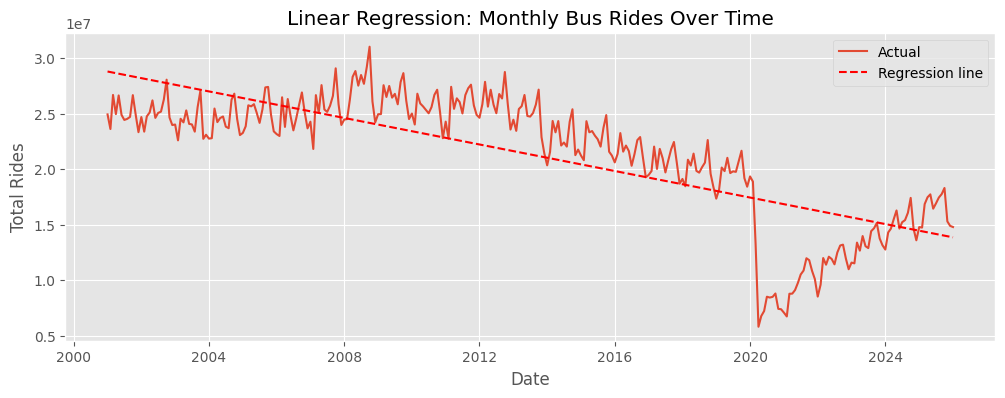


=== K-Means Clustering: Bus Routes by Ridership ===
            mean     std
cluster                 
0         1577.8   703.6
1        16304.0  6417.8
2         7996.8  3106.3


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


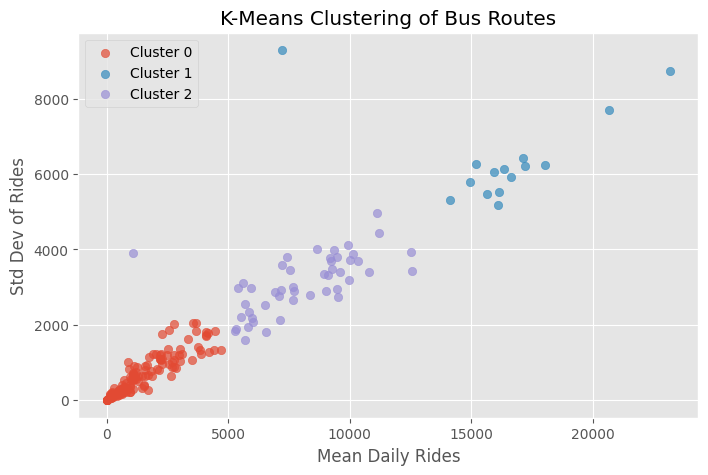

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np


# TECHNIQUE 1: Linear Regression - Predict Bus Rides Over Time

# Aggregate total rides per month
ridership_monthly = chicago_bus_ridership_df.groupby(
    chicago_bus_ridership_df['date'].dt.to_period('M')
)['rides'].sum().reset_index()
ridership_monthly['date'] = ridership_monthly['date'].dt.to_timestamp()
ridership_monthly['month_num'] = np.arange(len(ridership_monthly))

X = ridership_monthly[['month_num']]
y = ridership_monthly['rides']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("=== Linear Regression: Rides Over Time ===")
print(f"Coefficient: {model.coef_[0]:.2f} (rides change per month)")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R² Score: {model.score(X, y):.4f}")

plt.figure(figsize=(12, 4))
plt.plot(ridership_monthly['date'], y, label='Actual')
plt.plot(ridership_monthly['date'], y_pred, 'r--', label='Regression line')
plt.xlabel('Date')
plt.ylabel('Total Rides')
plt.title('Linear Regression: Monthly Bus Rides Over Time')
plt.legend()
plt.grid(visible=True)
plt.show()


# TECHNIQUE 2: K-Means Clustering - Group Bus Routes by Ridership

# Summarize each route: mean and std of rides
route_stats = chicago_bus_ridership_df.groupby('route')['rides'].agg(['mean', 'std']).fillna(0).reset_index()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(route_stats[['mean', 'std']])

kmeans = KMeans(n_clusters=3, random_state=42)
route_stats['cluster'] = kmeans.fit_predict(X_cluster)

print("\n=== K-Means Clustering: Bus Routes by Ridership ===")
print(route_stats.groupby('cluster')[['mean', 'std']].mean().round(1))

plt.figure(figsize=(8, 5))
for cluster in sorted(route_stats['cluster'].unique()):
    subset = route_stats[route_stats['cluster'] == cluster]
    plt.scatter(subset['mean'], subset['std'], label=f'Cluster {cluster}', alpha=0.7)

plt.xlabel('Mean Daily Rides')
plt.ylabel('Std Dev of Rides')
plt.title('K-Means Clustering of Bus Routes')
plt.legend()
plt.grid(visible=True)
plt.show()

### Q2.2

 For each example, describe how you applied the analytical method (e.g., regression, clustering, machine learning) to your dataset. Explain any data cleaning, feature selection, or transformation processes you used. How did you ensure that the method was applied correctly and that the results were reliable? 


For the linear regression, I aggregated the bus ridership data into monthly totals and used the month number as the input feature to predict total rides over time. For K-Means clustering, I summarized each bus route by its mean and standard deviation of daily rides, then standardized those features using StandardScaler before fitting the model with 3 clusters. The R² score of 0.60 for the regression and the clear separation of low, medium, and high ridership clusters in the scatter plot both indicate the methods were applied correctly and produced meaningful results.

### Q2.3

Identify any patterns or insights you discovered through the analysis. Explain how these findings contribute to understanding the research challenge.

The declining ridership trend aligns directly with the project's focus on transit equity, as a long-term drop of roughly 50,000 rides per month suggests the CTA has been losing riders steadily, likely accelerated by the 2008 recession and COVID-19 as outlined in the proposal. The three route clusters map well onto the policy archetypes described in the proposal, where cluster 1 routes averaging over 16,000 daily rides represent high-demand commuter corridors, while cluster 0 routes averaging under 1,600 likely serve as essential but underutilized routes in lower-density or underserved neighborhoods. These findings set the foundation for the next steps in the project, particularly connecting low-ridership routes to demographic and population data to understand whether service reductions are hitting the communities most dependent on public transit the hardest.

### Q 2.4

What are some challenges you encountered during the process and how did you address them. 

One challenge was that the rides column was stored as a string with commas rather than a numeric type, which would have caused errors in any mathematical operations, so each comma was stripped out and the column was converted to an integer before analysis. Another issue was that the bus ridership CSV had mixed data types in several columns which triggered a DtypeWarning on import, and this was addressed by explicitly converting the route column to a string type after loading. The perms and cafe arrays from earlier in the notebook also turned out to be multi-dimensional rather than flat 1D arrays, which caused numpy to throw a TypeError during polynomial regression, and calling flatten() on both arrays before passing them to polyfit resolved it.

### Q 3

Based on the insights derived from the analysis, what potential areas for improvement did your analysis reveal and what specific actions would you suggest to address these issues? How can the findings from your analysis be used to develop strategies to improve the current situation.

The steady decline in monthly ridership over the past two decades suggests the CTA should prioritize understanding why riders are leaving the system, and one concrete action would be to cross-reference the low-ridership cluster 0 routes with the population dataset to identify whether those routes serve neighborhoods with growing or stable populations that are simply being underserved by infrequent or unreliable service. The clustering results showing that a small number of high-ridership routes carry the bulk of demand points to a resource allocation problem where the CTA may be spreading service too thin across low-demand routes instead of reinforcing the corridors that riders actually depend on, and reallocating frequency to cluster 1 routes during peak hours could improve reliability for the most transit-dependent commuters. Looking ahead, the next phase of the project connecting routes to ZIP code demographics through the GTFS stop density mapping could make these recommendations much more specific, allowing the CTA and community advocates to pinpoint exactly which neighborhoods need service protection and make a data-backed case against cuts to essential routes in low-income areas.